# Visual Test for data_loader_ver2

This notebook mirrors `tests/test_data_loader_ver2.py` and checks the simple 3D image/label generator.

In [1]:
import shutil
import sys
from pathlib import Path

if Path.cwd().name == 'tests':
    sys.path.insert(0, str(Path.cwd().parent))
else:
    sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np

from data_loader_ver2 import find_image_label_pairs, load_image_label, my_3d_data_loader

test_dir = Path('temp_test_data_ver2_notebook')
images_dir = test_dir / 'images'
labels_dir = test_dir / 'labels'

if test_dir.exists():
    shutil.rmtree(test_dir)
images_dir.mkdir(parents=True)
labels_dir.mkdir(parents=True)

print("Setup complete")


Setup complete


In [2]:
num_samples = 5
volume_shape = (32, 32, 16)

for index in range(num_samples):
    name = f"sample_{index:03d}"
    image = np.random.rand(*volume_shape).astype(np.float32)
    label = (np.random.rand(*volume_shape) > 0.5).astype(np.uint8)

    nib.save(nib.Nifti1Image(image, np.eye(4)), images_dir / f"{name}_img.nii")
    nib.save(nib.Nifti1Image(label, np.eye(4)), labels_dir / f"{name}_mask.nii")

print("Created fake image files:", len(list(images_dir.glob("*_img.nii"))))
print("Created fake label files:", len(list(labels_dir.glob("*_mask.nii"))))


Created fake image files: 5
Created fake label files: 5


In [3]:
pairs = find_image_label_pairs(images_dir, labels_dir)
print("Pairs found:", len(pairs))
print("First image path:", pairs[0][0])
print("First label path:", pairs[0][1])


Pairs found: 5
First image path: temp_test_data_ver2_notebook/images/sample_000_img.nii
First label path: temp_test_data_ver2_notebook/labels/sample_000_mask.nii


In [4]:
image, label = load_image_label(*pairs[0], normalize=False)
print("Image shape:", image.shape)
print("Label shape:", label.shape)
print("Image dtype:", image.dtype)
print("Label dtype:", label.dtype)


Image shape: (1, 32, 32, 16)
Label shape: (1, 32, 32, 16)
Image dtype: float32
Label dtype: int64


In [5]:
batch_size = 2
generator = my_3d_data_loader(
    batch_size,
    images_dir=images_dir,
    labels_dir=labels_dir,
    normalize=False,
)

batch_images, batch_labels = next(generator)
print("Batch image shape:", batch_images.shape)
print("Batch label shape:", batch_labels.shape)


Batch image shape: (2, 1, 32, 32, 16)
Batch label shape: (2, 1, 32, 32, 16)


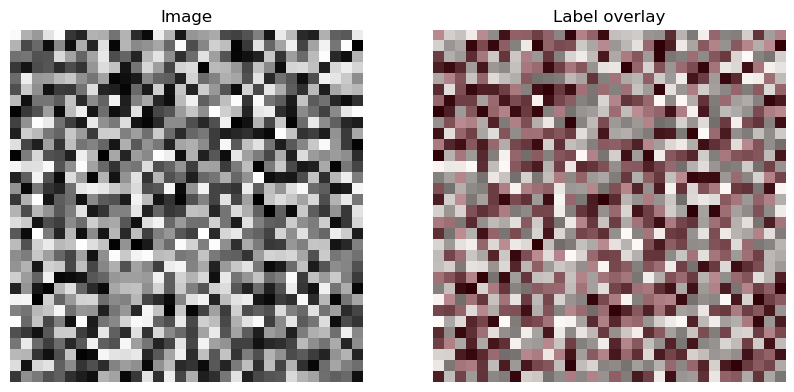

In [6]:
slice_idx = image.shape[-1] // 2
image_slice = image[0, :, :, slice_idx]
label_slice = label[0, :, :, slice_idx]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image_slice, cmap='gray')
axes[0].set_title('Image')
axes[0].axis('off')

axes[1].imshow(image_slice, cmap='gray')
axes[1].imshow(label_slice, cmap='Reds', alpha=0.45)
axes[1].set_title('Label overlay')
axes[1].axis('off')
plt.show()


In [8]:
CLEAN_UP = True

if CLEAN_UP and test_dir.exists():
    shutil.rmtree(test_dir)
    print("Removed", test_dir)
else:
    print("Keeping temporary files for inspection:", test_dir)


Removed temp_test_data_ver2_notebook
